#import required libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Load the dataset

In [26]:
df = pd.read_csv("../data/german_credit_data.csv")


#Display first five records

In [27]:
df.head()

,CustomerID,CheckingStatus,LoanDuration,CreditHistory,LoanPurpose,LoanAmount,ExistingSavings,EmploymentDuration,InstallmentPercent,Sex,...,OwnsProperty,Age,InstallmentPlans,Housing,ExistingCreditsCount,Job,Dependents,Telephone,ForeignWorker,Risk
0,713a336c-a255-4e2d-9d57-90b3e99e2f06,0_to_200,31,credits_paid_to_date,other,1889,100_to_500,less_1,3,female,...,savings_insurance,32,none,own,1,skilled,1,none,yes,No Risk
1,140b363f-a3fe-4828-a33f-7284dfdb3969,less_0,18,credits_paid_to_date,car_new,462,less_100,1_to_4,2,female,...,savings_insurance,37,stores,own,2,skilled,1,none,yes,No Risk
2,43b7b51d-5eda-4860-b461-ebef3d3436f4,less_0,15,prior_payments_delayed,furniture,250,less_100,1_to_4,2,male,...,real_estate,28,none,own,2,skilled,1,yes,no,No Risk
3,f40eaf08-e6d1-4765-ab20-c5f7faca1635,0_to_200,28,credits_paid_to_date,retraining,3693,less_100,greater_7,3,male,...,savings_insurance,32,none,own,1,skilled,1,none,yes,No Risk
4,1728910a-d3ff-4799-ac50-203a3a58a3fb,no_checking,28,prior_payments_delayed,education,6235,500_to_1000,greater_7,3,male,...,unknown,57,none,own,2,skilled,1,none,yes,Risk


#Understand Dataset Structure

In [28]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   CustomerID                5000 non-null   object
 1   CheckingStatus            5000 non-null   object
 2   LoanDuration              5000 non-null   int64 
 3   CreditHistory             5000 non-null   object
 4   LoanPurpose               5000 non-null   object
 5   LoanAmount                5000 non-null   int64 
 6   ExistingSavings           5000 non-null   object
 7   EmploymentDuration        5000 non-null   object
 8   InstallmentPercent        5000 non-null   int64 
 9   Sex                       5000 non-null   object
 10  OthersOnLoan              5000 non-null   object
 11  CurrentResidenceDuration  5000 non-null   int64 
 12  OwnsProperty              5000 non-null   object
 13  Age                       5000 non-null   int64 
 14  InstallmentPlans        

#Check Dataset Shape

In [29]:
df.shape


(5000, 22)

#Display Column Names

In [30]:
df.columns

Index(['CustomerID', 'CheckingStatus', 'LoanDuration', 'CreditHistory',
       'LoanPurpose', 'LoanAmount', 'ExistingSavings', 'EmploymentDuration',
       'InstallmentPercent', 'Sex', 'OthersOnLoan', 'CurrentResidenceDuration',
       'OwnsProperty', 'Age', 'InstallmentPlans', 'Housing',
       'ExistingCreditsCount', 'Job', 'Dependents', 'Telephone',
       'ForeignWorker', 'Risk'],
      dtype='object')

#Check Null Values

In [31]:
df.isnull().sum()

CustomerID                  0
CheckingStatus              0
LoanDuration                0
CreditHistory               0
LoanPurpose                 0
LoanAmount                  0
ExistingSavings             0
EmploymentDuration          0
InstallmentPercent          0
Sex                         0
OthersOnLoan                0
CurrentResidenceDuration    0
OwnsProperty                0
Age                         0
InstallmentPlans            0
Housing                     0
ExistingCreditsCount        0
Job                         0
Dependents                  0
Telephone                   0
ForeignWorker               0
Risk                        0
dtype: int64

#Check Total Duplicates

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.describe

<bound method NDFrame.describe of                                 CustomerID CheckingStatus  LoanDuration  \
0     713a336c-a255-4e2d-9d57-90b3e99e2f06       0_to_200            31   
1     140b363f-a3fe-4828-a33f-7284dfdb3969         less_0            18   
2     43b7b51d-5eda-4860-b461-ebef3d3436f4         less_0            15   
3     f40eaf08-e6d1-4765-ab20-c5f7faca1635       0_to_200            28   
4     1728910a-d3ff-4799-ac50-203a3a58a3fb    no_checking            28   
...                                    ...            ...           ...   
4995  e77fa77b-78da-4607-a2fa-ede36c1e968f    greater_200            27   
4996  6e71db4b-375c-42e1-b4a8-3292c007967a       0_to_200            11   
4997  db501d22-e0c9-4f38-bf05-7f2c1df35395    no_checking            32   
4998  802055d6-6aa7-4532-bf1c-0b8b114b483d       0_to_200            38   
4999  53094239-82f4-4b14-b2e9-7a0355a10839         less_0            12   

               CreditHistory LoanPurpose  LoanAmount ExistingSavi

#Convert Target Variable into Numerical Format


In [34]:
df["Target"] = df["Risk"].map({
    "No Risk" : 0,
    "Risk" : 1
})

#Check Target Variable Distribution

In [35]:
df['Target'].value_counts()

Target
0    3330
1    1670
Name: count, dtype: int64

#Drop Original Target Column

In [36]:
df.drop(columns=["Risk"], inplace=True)


#Import ScorecardPy Library for WOE and IV

In [37]:
import scorecardpy as sc

#Drop CustomerID Table

In [38]:
df.drop(columns=["CustomerID"], inplace=True)

#Calculate Weight Of Evidence

In [39]:
bins = sc.woebin(df, y = "Target")

[INFO] creating woe binning ...


d:\anaconda3\envs\ds311\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
d:\anaconda3\envs\ds311\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
d:\anaconda3\envs\ds311\Lib\site-packages\scorecardpy\condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure pars

Binning on 5000 rows and 21 columns in 00:00:17


#Apply WOE Transformation

In [40]:
df_woe = sc.woebin_ply(df, bins)
df_woe.head()

[INFO] converting into woe values ...


,Target,OthersOnLoan_woe,LoanDuration_woe,OwnsProperty_woe,Age_woe,Housing_woe,LoanPurpose_woe,LoanAmount_woe,Dependents_woe,InstallmentPercent_woe,...,CreditHistory_woe,CurrentResidenceDuration_woe,Telephone_woe,Job_woe,ExistingCreditsCount_woe,InstallmentPlans_woe,ExistingSavings_woe,Sex_woe,EmploymentDuration_woe,ForeignWorker_woe
0,0,-0.331032,0.940983,-0.379754,-0.758817,-0.059886,0.864044,-0.338697,-0.225472,-0.107571,...,-0.610274,0.068618,-0.733107,0.05426,-0.839247,0.225317,-0.025591,-0.176817,-1.727212,0.0
1,0,-0.331032,-0.985779,-0.379754,0.118906,-0.059886,-1.256971,-2.020882,-0.225472,-1.062996,...,-0.610274,-1.069216,-0.733107,0.05426,0.851202,-0.534390,-1.142433,-0.176817,-0.469256,0.0
2,0,-0.331032,-0.985779,-2.222784,-0.758817,-0.059886,0.010485,-2.020882,-0.225472,-1.062996,...,0.298504,0.068618,0.825371,0.05426,0.851202,0.225317,-1.142433,0.102963,-0.469256,0.0
3,0,-0.331032,0.153878,-0.379754,-0.758817,-0.059886,-0.382576,-0.338697,-0.225472,-0.107571,...,-0.610274,-1.069216,-0.733107,0.05426,-0.839247,0.225317,-1.142433,0.102963,1.583967,0.0
4,1,-0.331032,0.153878,1.688403,2.263384,-0.059886,0.406262,0.721255,-0.225472,-0.107571,...,0.298504,0.068618,-0.733107,0.05426,0.851202,0.225317,0.670588,0.102963,1.583967,0.0


#Display Information Values (IV) of Features

In [41]:
iv_df = sc.iv(df, y="Target")
iv_df

,variable,info_value
4,Age,1.181317
16,EmploymentDuration,1.166943
3,OwnsProperty,1.146858
2,LoanDuration,1.131470
0,CreditHistory,1.001729
5,CurrentResidenceDuration,0.981501
19,CheckingStatus,0.968005
18,InstallmentPercent,0.933204
9,ExistingCreditsCount,0.739347
7,Housing,0.697385


#Import library for VIF Calculation

In [42]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Select Independent variable

In [43]:
X = df_woe.drop(columns=["Target"])

#Calculate VIF For Each Feature

In [44]:
vif = pd.DataFrame()

vif["feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

d:\anaconda3\envs\ds311\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,feature,VIF
0,OthersOnLoan_woe,1.335784
1,LoanDuration_woe,2.488374
2,OwnsProperty_woe,2.078755
3,Age_woe,2.474314
4,Housing_woe,1.975027
5,LoanPurpose_woe,1.598889
6,LoanAmount_woe,2.988171
7,Dependents_woe,1.234966
8,InstallmentPercent_woe,3.480200
9,CheckingStatus_woe,2.805476


#Remove Weak feature

In [45]:
X = X.drop(columns=["ForeignWorker_woe"])
y = df_woe["Target"]

#Split Data Into Training and Testing Sets

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size = 0.25,
    random_state = 42,
    stratify = y
)

#Import Logistic Regression and GridSearchCV

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

#Create Logistic Regression Model

In [49]:
log_model = LogisticRegression(max_iter=1000)

#Define Hyperparameter Grid

In [52]:
param_grid = {
    "C" : [0.01, 0.1, 1, 10] ,
    "solver" : ["liblinear", "lbfgs"]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [53]:
grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv = 5,
    scoring="f1",
    n_jobs = -1
)

#Train Logistic Regression Model

In [54]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information pri

#Display Best Hyperparameters

In [55]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'C': 10, 'solver': 'liblinear'}
Best F1 Score : 0.6770936284567792


#Predict Target Values on Test Data

In [56]:
y_pred = grid_search.predict(X_test)

#Import Model Evaluation Metrics

In [57]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

#Evaluate Logistic Regression Model

In [58]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.8024
Precision : 0.7309782608695652
Recall : 0.645083932853717
F1 : 0.6853503184713375


#Display Confusion Matrix

In [59]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[734  99]
 [148 269]]


#Display Classification Report

In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86       833
           1       0.73      0.65      0.69       417

    accuracy                           0.80      1250
   macro avg       0.78      0.76      0.77      1250
weighted avg       0.80      0.80      0.80      1250



#Import Decision Tree and GridSearchCV

In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

#Create Decision Tree Classifier

In [63]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

#Define Hyperparameters for Decision Tree

In [64]:
param_grid = {
    "criterion" : ["gini", "entropy"],
    "max_depth" : [3, 5, 7, 10],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

#Perform Hyperparameter Tuning using GridSearchCV

In [65]:
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv = 5,
    scoring="f1",
    n_jobs=-1
)

#Train Decision Tree Model

In [66]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ve

#Display Best Hyperparameters

In [67]:
print("Best Parameters :", grid_search.best_params_)
print("Best F1 Score :", grid_search.best_score_)

Best Parameters : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best F1 Score : 0.613322761958236


#Predict Target Values on Test Dataset

In [68]:
y_pred = grid_search.predict(X_test)

#Import Evaluation Metrics

In [69]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

#Evaluate Decision Tree Model

In [70]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 :", f1)

Accuracy : 0.792
Precision : 0.7371601208459214
Recall : 0.5851318944844125
F1 : 0.6524064171122995


#Display Confusion Matrix

In [71]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[746  87]
 [173 244]]


#Display Classification Report

In [72]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       833
           1       0.74      0.59      0.65       417

    accuracy                           0.79      1250
   macro avg       0.77      0.74      0.75      1250
weighted avg       0.79      0.79      0.79      1250



#Display Feature Importance

In [73]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": grid_search.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                         Feature  Importance
9             CheckingStatus_woe    0.433791
18        EmploymentDuration_woe    0.198889
2               OwnsProperty_woe    0.123329
0               OthersOnLoan_woe    0.098552
17                       Sex_woe    0.067369
11  CurrentResidenceDuration_woe    0.019920
14      ExistingCreditsCount_woe    0.014425
6                 LoanAmount_woe    0.011231
1               LoanDuration_woe    0.009260
15          InstallmentPlans_woe    0.006481


### This tells us which features contributed the most to the Decision Tree.

#Visualize Decision Tree

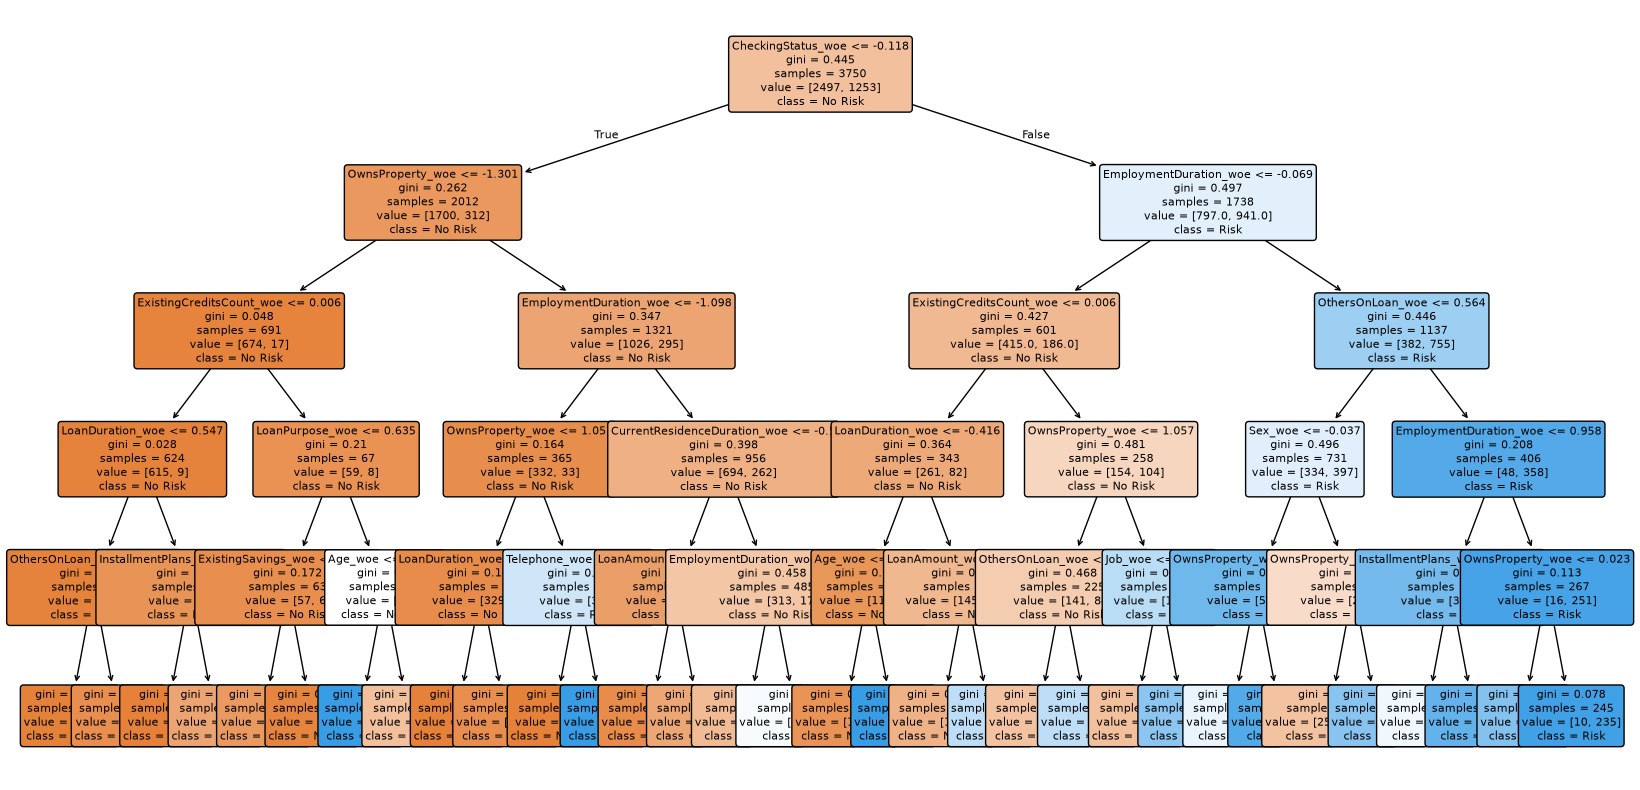

In [75]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    grid_search.best_estimator_,
    feature_names = X.columns,
    class_names=["No Risk", "Risk"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

# Final Conclusion


## Model Comparison

### Logistic Regression achieved higher Accuracy,
### Recall and F1 Score than Decision Tree.
### Therefore, Logistic Regression is selected
### as the better model for this dataset.